[Home](../../README.md)

### Model Training - Polynomial Regression

Linear regression assumes the data has a linear pattern. If your data does not have a linear pattern you can consider a polynomial regression algorithm that provides a multi (poly) coefficient linear relationship between an independent variable and a dependent variable to predict the outcome of future events. We will now Train a Polynomial regression algorithm on the features you have engineered to see how closely we can predict the health outcomes for individuals.

#### Step 1

Load the required dependencies:

In [1]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
plt.style.use('../../style_Matplotlib_charts.mplstyle')
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pickle

#### Step 2

Store the data columns for Linear Regression.

In [2]:
# Create a data frame from the csv file
training_data = pd.read_csv('2.3.2.training_data.csv')

x_name = ['events_completed']
y_name = 'average'
x = np.array(training_data[x_name]).flatten()
y = np.array(training_data[y_name])

#### Step 3

Plot the feature `x` and target `y` data on a graph using the column headings as the graph labels.

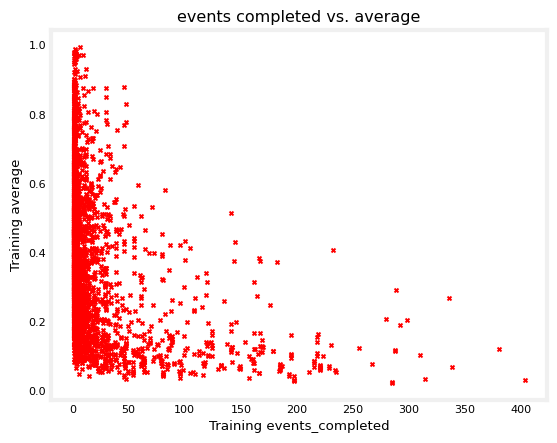

In [3]:
if(len(x_name) == 1):
    plt.scatter(x, y, marker='x', c='r', s=1)
    plt.title("events completed vs. average")
    plt.ylabel(f'Training {y_name}')
    plt.xlabel(f'Training {x_name[0]}')
else:
    fig,ax=plt.subplots(1,len(x_name),figsize=(12,3))
    for i in range(len(ax)):
        ax[i].scatter(x[:,i],y, label = 'target')
        ax[i].set_xlabel(x_name[i])
    ax[0].set_ylabel("average"); ax[0].legend();
    fig.suptitle("events completed vs. average")
plt.show()

this graph proved to be the best because...

I then decided to get rid of some of the noise and outliers...

In [4]:
df_t = pd.DataFrame({'x' : x, 'y': y})

df_t['bin'] = pd.cut(df_t['x'], bins=50)
binned = df_t.groupby("bin", observed=True)["y"].mean().reset_index()
binned["x_mid"] = binned["bin"].apply(lambda b: b.mid)

binned = binned.dropna()

x_binned = binned['x_mid'].values.astype(float)
y_binned = binned['y'].values.astype(float)

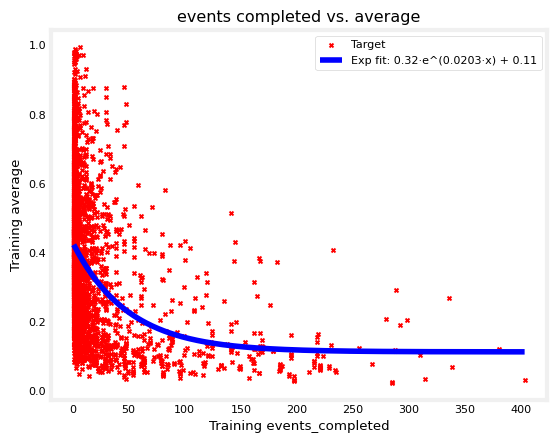

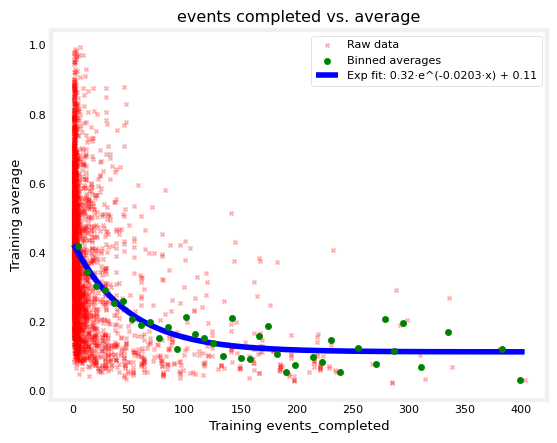

In [5]:
def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c

params, covariance = curve_fit(exp_func, x_binned, y_binned, p0=[1, 0.01, 0.1], maxfev=10000)
a, b, c, = params

x_sorted = np.linspace(x.min(), x.max(), 300)
y_pred = exp_func(x_sorted, a, b, c)
y_pred_points = exp_func(x, a, b, c)

plt.scatter(x, y, marker='x', c='r', s=1, label='Target')
plt.plot(x_sorted, y_pred, color='blue', label=f'Exp fit: {a:.2f}·e^({b:.4f}·x) + {c:.2f}')
plt.title("events completed vs. average")
plt.ylabel(f'Training {y_name}')
plt.xlabel(f'Training {x_name[0]}')
plt.legend()
plt.show()


plt.scatter(x, y, marker='x', c='r', s=1, label='Raw data', alpha=0.3)
plt.scatter(x_binned, y_binned, c='green', s=20, zorder=5, label='Binned averages')
plt.plot(x_sorted, y_pred, color='blue', label=f'Exp fit: {a:.2f}·e^(-{b:.4f}·x) + {c:.2f}')
plt.title("events completed vs. average")
plt.ylabel(f'Training {y_name}')
plt.xlabel(f'Training {x_name[0]}')
plt.legend()
plt.show()

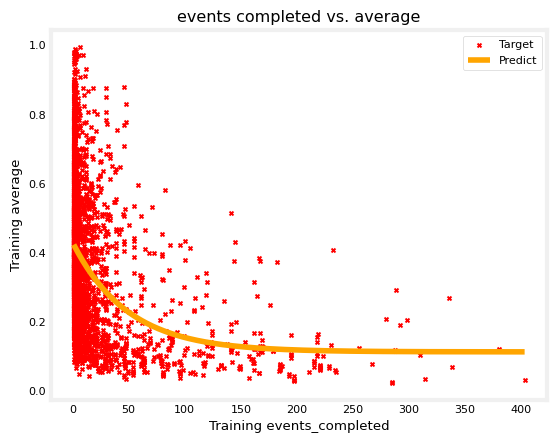

In [6]:
y_pred_points = exp_func(x, a, b, c)

if len(x_name) == 1:
    plt.scatter(x, y, marker="x", c="r", s=1, label="Target")
    plt.plot(x_sorted, exp_func(x_sorted, a, b, c), c="orange", label="Predict")  # use line instead
    plt.title("events completed vs. average")
    plt.ylabel(f"Training {y_name}")
    plt.xlabel(f"Training {x_name[0]}")
    plt.legend()
plt.show()

### Step 4

Then save an instance of PolynomialFeatures, adjust the 'degree' parameter to suit your model and create the feature using the data in 'x'. (Note a degree of 1 is linear regression, each extra degree adds a coefficient).

Then use the [Scikit-learn](https://scikit-learn.org/stable/) library to instantiate a Machine Learning model class and store it in the `my_model` variable as an object.

In [7]:
# poly = PolynomialFeatures(degree=50, include_bias=False)
# poly_features = poly.fit_transform(x.reshape(-1, 1))

# # Create the model
# my_model = LinearRegression()
# # Fit the model to the data
# my_model.fit(poly_features, y)

#### Step 5

Plot the features, targets and model (linear regression).

In [8]:
# y_pred = my_model.predict(poly_features)
# if(len(x_name) == 1):
#     plt.scatter(x, y_pred)
#     plt.scatter(x, y, marker='x', c='r', s=1)
#     plt.title("events completed vs. average")
#     plt.ylabel(f'Training {y_name}')
#     plt.xlabel(f'Training {x_name[0]}')
# else:
#     fig,ax=plt.subplots(1,len(x_name),figsize=(12,3),sharey=True)
#     for i in range(len(ax)):
#         ax[i].scatter(x[:,i],y, label = 'target')
#         ax[i].set_xlabel(x_name[i])
#         ax[i].scatter(x[:,i],y_pred,color="orange", label = 'predict')
#     ax[0].set_ylabel("average"); ax[0].legend();
#     fig.suptitle("events completed vs. average")
# plt.show()

In [9]:
# # save the poly to disk
# poly_filename = 'my_saved_poly_v3.pkl'
# pickle.dump(poly, open('../2.4.Model_Testing_and_Validation/' + poly_filename, 'wb'))

# # save the model to disk
# model_filename = 'my_saved_model_v3.sav'
# pickle.dump(my_model, open('../2.4.Model_Testing_and_Validation/' + model_filename, 'wb'))

#### Step 6. Explore polynomial degrees

Students should now use the best features from Multiple Fetaure Linear Regression and apply some polynomial degrees to see if they can further improve the intuation of their model without overfitting.